In [ ]:
# June 22, 2026
# 02 Hello World

# Create and Run a Simple Quantum Program

# Step 1: importing required libararies
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

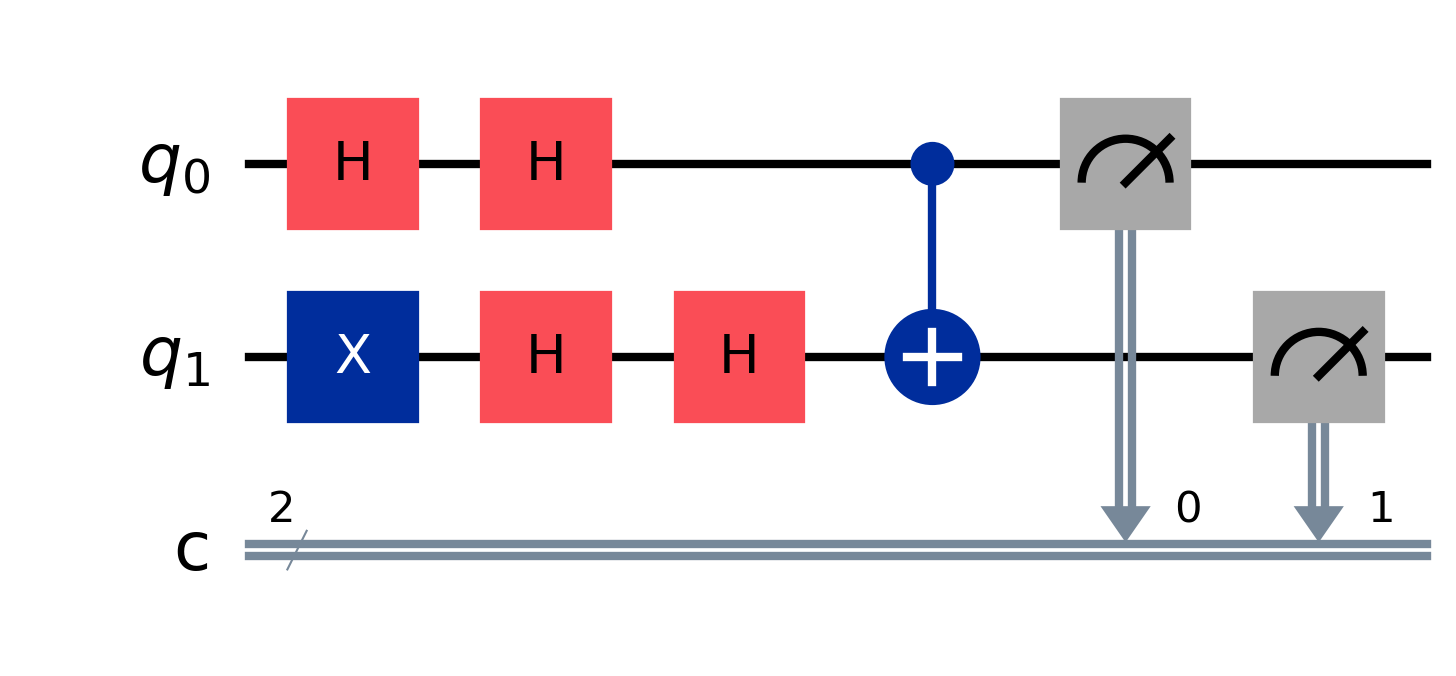

In [ ]:
# Step 2: defining the quantum circuit
circuit = QuantumCircuit(2, 2)

# this creates 2 qubits and 2 classical bits

# Step 3: Applying Quantum Gates
# apply X gate on qubit 1
circuit.x(1)
circuit.h(0)        # apply H gate on qubit 0
circuit.h(1)        # apply H gate on qubit 1
   # apply CX gate with control on qubit 0 and target on qubit 1
circuit.h(0)
circuit.h(1)        # apply H gate again
circuit.cx(0, 1) 
# Step 4: meausure the qubits
# measure qubit 1, store in classical bit 1
circuit.measure(0, 0)

# measure qubit 2, store in classical bit 2
circuit.measure(1, 1)

# visualize
circuit.draw('mpl', idle_wires=False, scale=3)




In [3]:
# Step 5: Optimizing the Circuit
import json
with open("config.json", "r") as f:
    config = json.load(f)

API_KEY = config["IBM_API_KEY"]
INSTANCE = config["IBM_INSTANCE"]

service = QiskitRuntimeService(channel="ibm_quantum_platform", token=API_KEY)

backend = service.least_busy(simulator=False, operational=True)
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

isa_circuit = pm.run(circuit)

qiskit_runtime_service._discover_account:WARNING:2026-06-23 18:54:08,473: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-06-23 18:54:11,578: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-23 18:54:11,876: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-23 18:54:14,198: Using instance: open-instance, plan: open


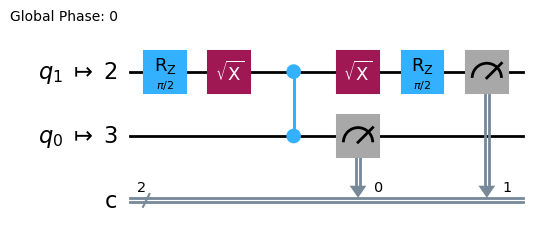

In [4]:
# Step 6: visualizing the optimized circuit
isa_circuit.draw('mpl', idle_wires=False)

In [5]:
# print backend names
print(backend.name)
print(backend.num_qubits)

# Step 7: Sampling and Running the Circuit
sampler = Sampler(backend)
job = sampler.run([isa_circuit])
result = job.result()

ibm_marrakesh
156


In [6]:
# Step 8: extracting and printing results
databin = result[0].data

bitstrings = databin.c.get_bitstrings()
counts = databin.c.get_counts()

print(bitstrings)
print(counts)

['10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '00', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '00', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '11', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '00', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '00', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10', '10

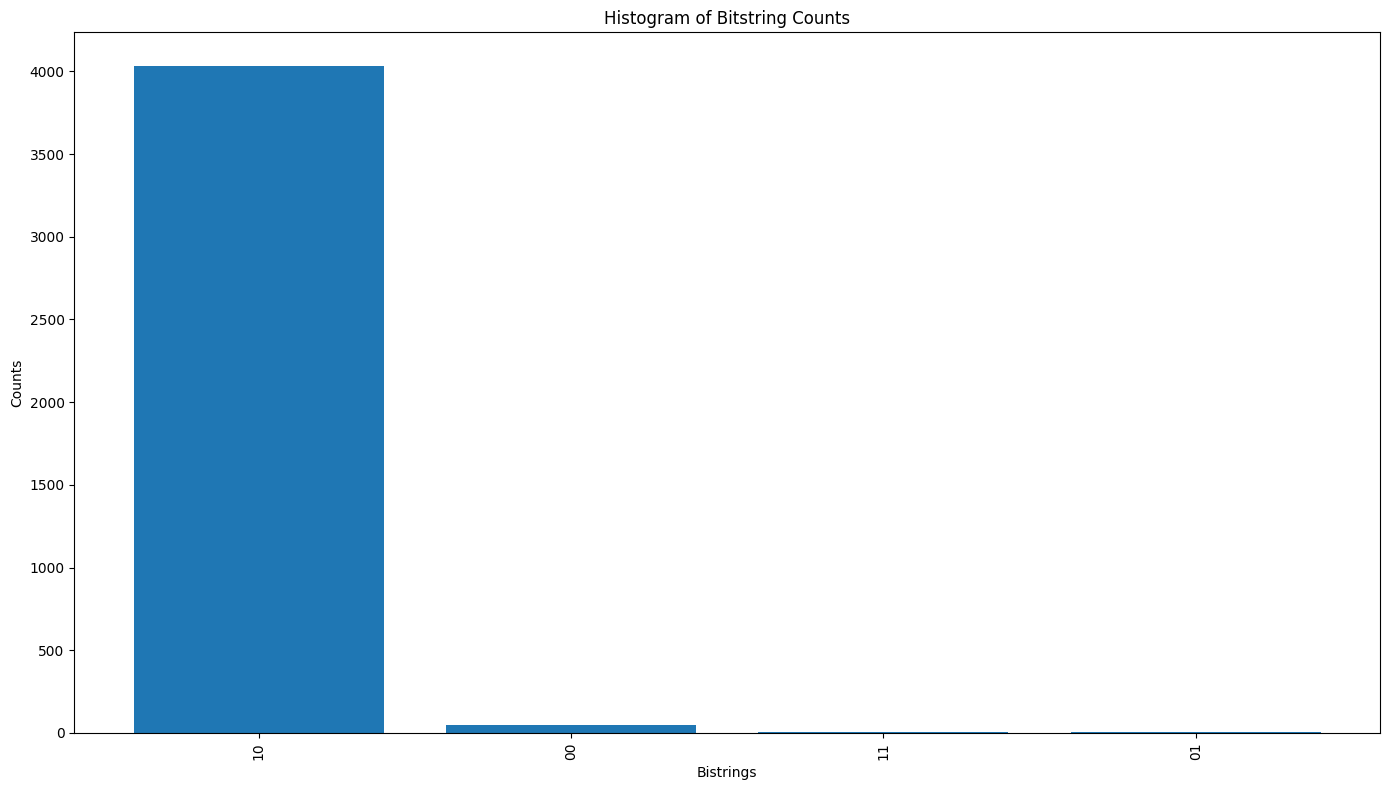

In [7]:
# Step 9: plotting results
import matplotlib.pyplot as plt

count_values = [counts[bitstring] for bitstring in bitstrings]

plt.figure(figsize=(14,8))
plt.bar(bitstrings, count_values)
plt.xlabel('Bistrings')
plt.ylabel('Counts')
plt.title('Histogram of Bitstring Counts')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# if you remove the X gate, then it becomes only ket 00
# if you swap the CNOT and the last two H gates, it becomes only ket 01